# Assignment: Frozen Lake

Name: Chris Hirschbrich


Learning Goals:
* Implement a Monte Carlo control method.
* Experiment with the impact of stochasticity on learning with Monte Carlo and TD control.

## Introduction

The Frozen Lake environment provided by Gymnasium is a small toy example for stochastic actions. We have introduced it in
the [Frozen Lake Notebook](frozen_lake_MC.ipynb). In this exercise, you will implement a different MC control method and experiment with
different settings for the environment.

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
%%capture

# Gymnasium Installation
%pip install swig
%pip install gymnasium[box2d,classic_control]
%pip install pyvirtualdisplay
%pip install gymnasium[other]


# Modified Gym-classics Installation
!git clone https://github.com/mhahsler/gym-classics.git
!cd gym-classics;git pull
!cd gym-classics; pip install -e .

import sys
sys.path.insert(0, "/content/gym-classics")
import gym_classics
print("Imported via sys.path:", gym_classics.__file__)

## Helper Code

Copy all imports and helper functions you need from the [Frozen Lake Notebook](frozen_lake_MC.ipynb) below.

In [2]:
import numpy as np
np.set_printoptions(precision=2)
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

In [3]:
# Used for Google Colab
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py",
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/common/")

## Task 1: Implement Monte Carlo Control with $\epsilon$-soft policy

It is crucial the MC Control methods have the ability to reach any possible state. MC Control with exploring does this by start episodes in the environment with a random state/action combination. This approach is often not possible; think physical environments or very complicated simulations. Monte Carlo control with an $\epsilon$-soft policy is another option to guarantee exploration.

Implement the algorithm. It can be found in the textbook and in the course slides. You will probably need to experiment and debug to make sure the code works right. Put your final version below.

In [4]:
from gym_classics.envs.abstract.gridworld import Gridworld
from typing import DefaultDict
from collections import defaultdict

def random_argmax(x):
    """argmax with random tie-breaking."""
    return np.random.choice(np.where(x == np.max(x))[0])

def policy_to_probs(policy_1d, n_actions):
    """Convert a 1D greedy policy (ints) to a 2D one-hot probability table."""
    n_states = len(policy_1d)
    probs = np.zeros((n_states, n_actions))
    for s in range(n_states):
        probs[s, policy_1d[s]] = 1.0
    return probs

def sample_episode(env, policy=None, start_state=None, start_action=None, max_len=1000, verbose=False):
    """
    Sample one episode.
    policy must be a 2D array of shape (n_states, n_actions) with probability rows,
    OR None (uses uniform random).
    """
    n_actions = env.action_space.n
    n_states  = env.observation_space.n

    if policy is None:
        policy = np.full((n_states, n_actions), 1.0 / n_actions)

    # If a 1D greedy policy was accidentally passed in, convert it
    if policy.ndim == 1:
        policy = policy_to_probs(policy, n_actions)

    episode = []
    s, info = env.reset()

    if start_state is not None:
        s = start_state
        if isinstance(env, Gridworld):
            env.state = env.unwrapped.decode(start_state)
        else:
            env.state = start_state

    step = 0
    done = False
    while not done and step < max_len:
        a = np.random.choice(n_actions, p=policy[s])   # ← correct: sample from probs

        if step == 0 and start_action is not None:
            a = start_action

        sp, reward, done, terminated, truncated = env.step(a)
        episode.append((s, a, reward, sp))

        if verbose:
            print("Step", step, "(s,a,r,s')=", s, a, reward, sp)

        s = sp
        step += 1

    return episode

In [5]:
def MC_Esoft(env, discount, n=100, Q=None, max_episode_len=100,
             history=False, verbose=False, epsilon=0.1):
    assert isinstance(env.action_space, gym.spaces.Discrete)
    assert isinstance(env.observation_space, gym.spaces.Discrete)

    n_actions = env.action_space.n
    n_states  = env.observation_space.n

    pi = np.full((n_states, n_actions), 1.0 / n_actions)

    Returns = DefaultDict(list)
    episode_returns = [] 

    if Q is None:
        Q = np.zeros((n_states, n_actions))

    if history:
        Q_list  = [Q.copy()]
        pi_list = [pi.copy()]
        ep_list = [None]

    for i in range(n):
        episode = sample_episode(env, pi, max_len=max_episode_len)
        G = 0
        visited_states = set() 
        
        # Update Q-values for all first-visit (s,a) pairs
        for t in range(len(episode) - 1, -1, -1):
            s_t, a_t, r_t, sp_t = episode[t]
            G = discount * G + r_t

            # First-visit check
            if (s_t, a_t) not in [(x[0], x[1]) for x in episode[:t]]:
                Returns[(s_t, a_t)].append(G)
                Q[s_t, a_t] = np.mean(Returns[(s_t, a_t)])
                visited_states.add(s_t)
        
        # Update policy for all visited states to be epsilon-soft
        for s in visited_states:
            A_star = random_argmax(Q[s, :])
            for a in range(n_actions):
                if a == A_star:
                    pi[s, a] = 1 - epsilon + epsilon / n_actions
                else:
                    pi[s, a] = epsilon / n_actions

        # Episode return = sum of rewards (undiscounted, for plotting)
        ep_return = sum(r for s, a, r, sp in episode)
        episode_returns.append(ep_return)

        if history:
            pi_list.append(pi.copy())
            Q_list.append(Q.copy())
            ep_list.append(episode)

    if history:
        return pi_list, Q_list, ep_list, episode_returns

    return pi, Q, episode_returns

## Task 2: Experiments

Compare MC Control with ES (you can use the code from class), MC Control with $\epsilon$-soft policy, and Q-Learning. Here are the detailed experiments:
For each experiment, you need to compare how fast the algorithms learn by plotting the number of episodes on the x-axis and the episode return on the y axis (see [4x3_grid_world_MC.ipynb] for an example). This measure will be way better suited to MC Control with $\epsilon$-soft policy, and Q-Learning. For Q-Learning you will need to to think about choosing the additional parameters.

Setup code and common functions go here:

In [ ]:
# Code borrowed from class:
from gym_classics.algorithms.policy import random_policy as gym_random_policy

def MC_control_ES(env, discount, n=100, max_episode_len=100):
    policy_1d = gym_random_policy(env)   # 1D greedy policy
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    Returns = defaultdict(list)
    episode_returns = []

    for i in range(n):
        s = np.random.choice(range(env.observation_space.n))
        a = np.random.choice(range(env.action_space.n))

        # Convert 1D policy → 2D probs so sample_episode works correctly
        policy_2d = policy_to_probs(policy_1d, env.action_space.n)
        episode   = sample_episode(env, policy_2d, start_state=s,
                                   start_action=a, max_len=max_episode_len)
        G = 0
        visited = [(s, a) for s, a, r, sp in episode]

        for t in range(len(episode) - 1, -1, -1):
            s, a, r, sp = episode[t]
            G = discount * G + r
            if (s, a) not in visited[:t]:
                Returns[(s, a)].append(G)
                Q[s, a]    = np.mean(Returns[(s, a)])
                policy_1d[s] = random_argmax(Q[s, :])

        ep_return = sum(r for s, a, r, sp in episode)
        episode_returns.append(ep_return)

    return policy_1d, Q, episode_returns


In [ ]:
def Q_learning(env, discount, alpha, epsilon, n=100):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = []

    for i in range(n):
        s, _ = env.reset()
        done  = False
        ep_return = 0

        while not done:
            if np.random.random() > epsilon:
                a = random_argmax(Q[s, :])
            else:
                a = np.random.randint(env.action_space.n)

            sp, r, done, _, _ = env.step(a)
            Q[s, a] += alpha * (r + discount * np.max(Q[sp, :]) - Q[s, a])
            ep_return += r
            s = sp

        episode_returns.append(ep_return)

    return Q, episode_returns

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

def smooth(x, window=200):
    # Simple moving average for readability.
    return np.convolve(x, np.ones(window) / window, mode='valid')

def plot_learning_curves(results_dict, title, smooth_window=200):
    # Plot learning curves for multiple algorithms.
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, returns in results_dict.items():
        smoothed = smooth(returns, smooth_window)
        ax.plot(smoothed, label=label, linewidth=1.8)
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Return (smoothed over {smooth_window} ep)")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [2]:
%%capture

import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

def run_experiment(map_name, is_slippery, success_rate,
                   N=20000, discount=1, alpha=0.5, epsilon=0.1):

    env = gym.make(
        "FrozenLake-v1",
        render_mode="rgb_array",
        map_name=map_name,
        is_slippery=is_slippery,
        success_rate=success_rate,
        reward_schedule=(1,0,0)
    )

    print(f"\n--- map={map_name} | slippery={is_slippery} | success={success_rate} ---")

    _, _, mc_esoft_returns = MC_Esoft(
        env,
        discount=discount,
        n=N,
        epsilon=epsilon,
        max_episode_len=200
    )

    _, _, mc_es_returns = MC_control_ES(
        env,
        discount=discount,
        n=N,
        max_episode_len=200
    )

    _, ql_returns = Q_learning(
        env,
        discount=discount,
        alpha=alpha,
        epsilon=epsilon,
        n=N
    )

    plot_learning_curves(
        {
            "MC epsilon-soft": mc_esoft_returns,
            "MC with ES": mc_es_returns,
            "Q-Learning": ql_returns
        },
        title=f"FrozenLake (success={success_rate})",
        smooth_window=300
    )

    env.close()

The Frozen Lake environment has a stochastic transition function (the ice is slippery). The experiments modify the stochasticity from no slipping to very slippery ice and you will analyze the impact on the performance of the different algorithms.

### Experiment 1: Deterministic Environment
Use `map_name="4x4", is_slippery=True, success_rate=100.0/100.0`

Note: You could also just set ` is_slippery=False`


--- map=4x4 | slippery=False | success=1.0 ---


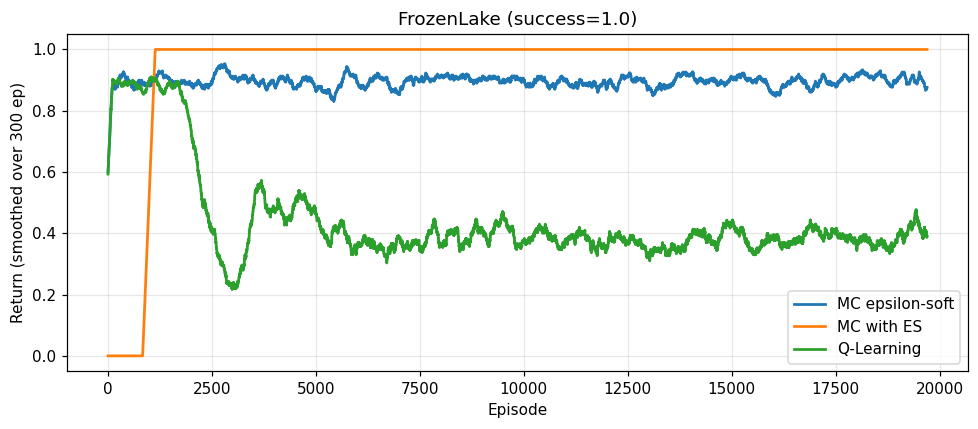

In [10]:
run_experiment(map_name="4x4", is_slippery=False, success_rate=100.0/100.0)

### Experiment 2: Environment with Low Stochasticity
Use `map_name="4x4", is_slippery=True, success_rate=90.0/100.0`



--- map=4x4 | slippery=True | success=0.9 ---


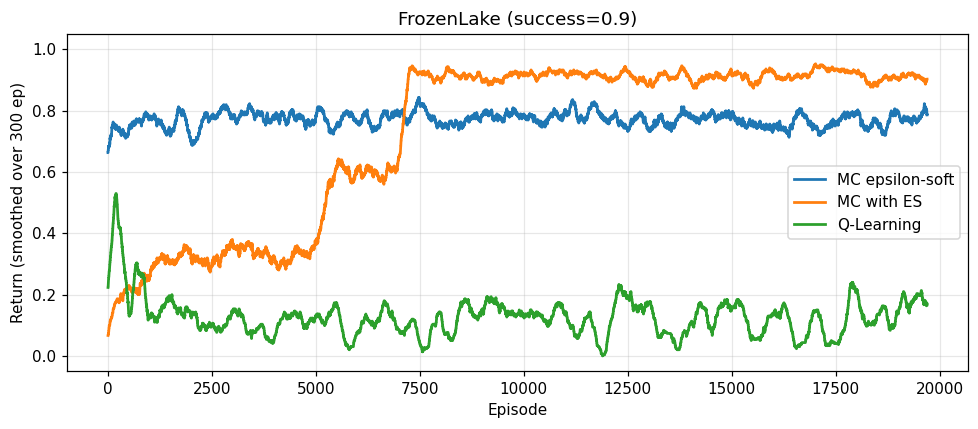

In [11]:
run_experiment(map_name="4x4", is_slippery=True, success_rate=90.0/100.0)

### Experiment 3: Environment with Medium Stochasticity
Use `map_name="4x4", is_slippery=True, success_rate=70.0/100.0`



--- map=4x4 | slippery=True | success=0.7 ---


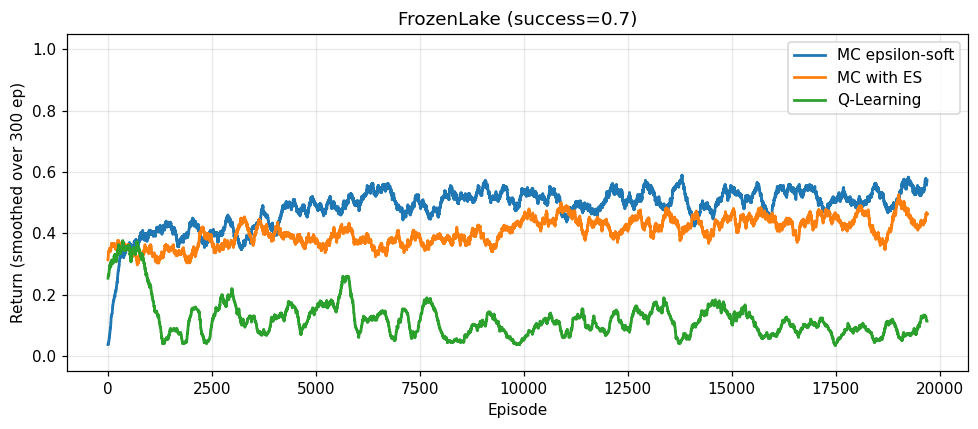

In [12]:
run_experiment(map_name="4x4", is_slippery=True, success_rate=70.0/100.0)

### Experiment 4: Environment with High Stochasticity
Use `map_name="4x4", is_slippery=True, success_rate=50.0/100.0`


--- map=4x4 | slippery=True | success=0.5 ---


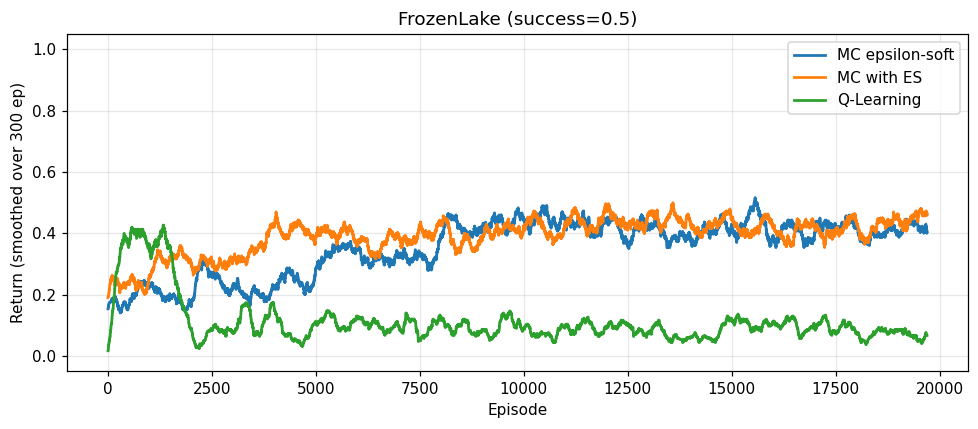

In [13]:
run_experiment(map_name="4x4", is_slippery=True, success_rate=50.0/100.0)

## Task 3: Discussion

Describe how the three algorithm's performance compares and how it depends on the amount of stochasticity in the environment. How would you choose a good number of episodes? How do you choose the parameters for Q-Learning?

### Monte Carlo $\epsilon$-soft policy
MC $\epsilon$-soft did well across the board and followed the expected results, given the stochastic enviornments. In the deterministic environment, it hovered at around 0.9 reward. This is because it has the 0.10 $\epsilon$ allowing it to explore. This, however, causes it to fall into the icy lake around 10% of the time. In the stochastic environments, the slippery ice adds on top of the epsilon exploration. For the 90% success rate, it subtracted another 0.10 reward. In the 70% stochastic env, it held at around a 0.60 reward, and in the 50%, it achieved ~0.40.

### Monte Carlo Exploring Starts policy
MC_ES performed very different when compared to the other two. In the deterministic environment, it found the best policy and stopped exploring afterwards, which is intended. This led it to have a return of 1 from episode ~1000. In the stochastic environments it generally performed on par with MC $\epsilon$-soft, beating it in the 90% environment, and about even in the other two. This balance between the two is due to learning from similar experience distributions, they both visit similarly diverse paths due to the chance of slipping. This leads me to observe that when the environment provides a lot of the exploration via stochasticity, the choice of exploration strategy matters less.

### Q-Learning policy
The Q-Learning policy struggled the most out of the three in every single experiment. It was never able to learn a policy that helped it in the deterministic environment, and suffered even more in the stochastic environments. It struggled most likely due to the reward structure, as it only got rewarded if it found the terminal state. As a result, it may have accidentally found a path that works, but is extremely dangerous when slippery. To look into this more, I decided to make an environment with a new reward structure to see if that would make a difference, and the results were much better. I ran the test many times with several alpha values ranging from 0.1 < $\alpha$ < 0.9, and found that 0.5 was the sweet spot. This maximized the total reward on the graphs by a decent amount while being more stable than the others. The return would be more volatile and $\alpha$ = 0.5 was the sweetspot that made the return pattern more observable.


### Extra Experiment: Q-Learning with Different Reward Structures

Since Q-Learning struggled with sparse rewards, I wanted to test how different reward structures affect its performance. The `reward_schedule` parameter is a tuple of `(goal_reward, hole_penalty, step_penalty)`:

- **Penalty for holes**: `(1, -1, 0)` - Punish falling in holes
- **Step penalty**: `(1, 0, -0.01)` - Small penalty each step to encourage efficiency
- **Combined**: `(1, -1, -0.01)` - Holes penalty + step penalty

In [14]:
def run_ql_reward_experiment(map_name, is_slippery, success_rate, 
                              reward_schedules, N=20000, discount=1, alpha=0.5, epsilon=0.1):
    """
    Run Q-Learning experiments with different reward structures.
    reward_schedules: dict of {'label': (goal_reward, hole_penalty, step_penalty)}
    """
    results = {}
    
    for label, reward_schedule in reward_schedules.items():
        env = gym.make(
            "FrozenLake-v1",
            render_mode="rgb_array",
            map_name=map_name,
            is_slippery=is_slippery,
            success_rate=success_rate,
            reward_schedule=reward_schedule
        )
        
        print(f"Running Q-Learning with {label}: {reward_schedule}")
        
        _, ql_returns = Q_learning(
            env,
            discount=discount,
            alpha=alpha,
            epsilon=epsilon,
            n=N
        )
        
        results[f"Q-Learning {label}"] = ql_returns
        env.close()
    
    plot_learning_curves(
        results,
        title=f"Q-Learning Reward Structures (success={success_rate})",
        smooth_window=300
    )

#### Reward Structure Experiment 1: Deterministic Environment

Running Q-Learning with Hole Penalty (1,-1,0): (1, -1, 0)
Running Q-Learning with Step Penalty (1,0,-0.01): (1, 0, -0.01)
Running Q-Learning with Combined (1,-1,-0.01): (1, -1, -0.01)


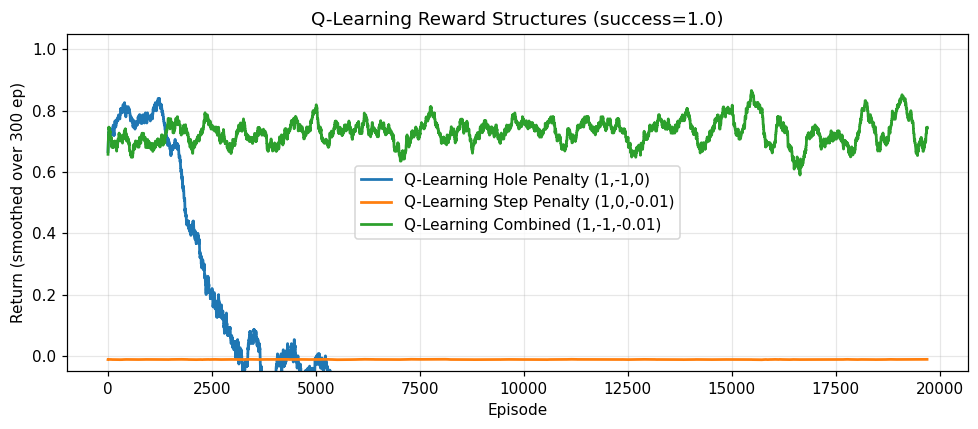

In [20]:
reward_structures = {
    "Hole Penalty (1,-1,0)": (1, -1, 0),
    "Step Penalty (1,0,-0.01)": (1, 0, -0.01),
    "Combined (1,-1,-0.01)": (1, -1, -0.01)
}

run_ql_reward_experiment(
    map_name="4x4", 
    is_slippery=False, 
    success_rate=100.0/100.0,
    reward_schedules=reward_structures
)

#### Reward Structure Experiment 2: Stochastic Environment (90%)

Running Q-Learning with Hole Penalty (1,-1,0): (1, -1, 0)
Running Q-Learning with Step Penalty (1,0,-0.01): (1, 0, -0.01)
Running Q-Learning with Combined (1,-1,-0.01): (1, -1, -0.01)


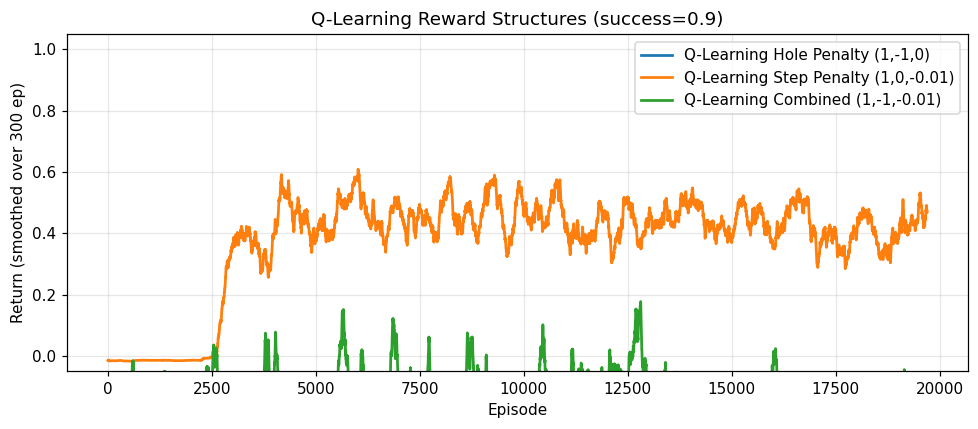

In [21]:
run_ql_reward_experiment(
    map_name="4x4", 
    is_slippery=True, 
    success_rate=90.0/100.0,
    reward_schedules=reward_structures
)

#### Reward Structure Experiment 3: Highly Stochastic Environment (50%)

Running Q-Learning with Hole Penalty (1,-1,0): (1, -1, 0)
Running Q-Learning with Step Penalty (1,0,-0.01): (1, 0, -0.01)
Running Q-Learning with Combined (1,-1,-0.01): (1, -1, -0.01)


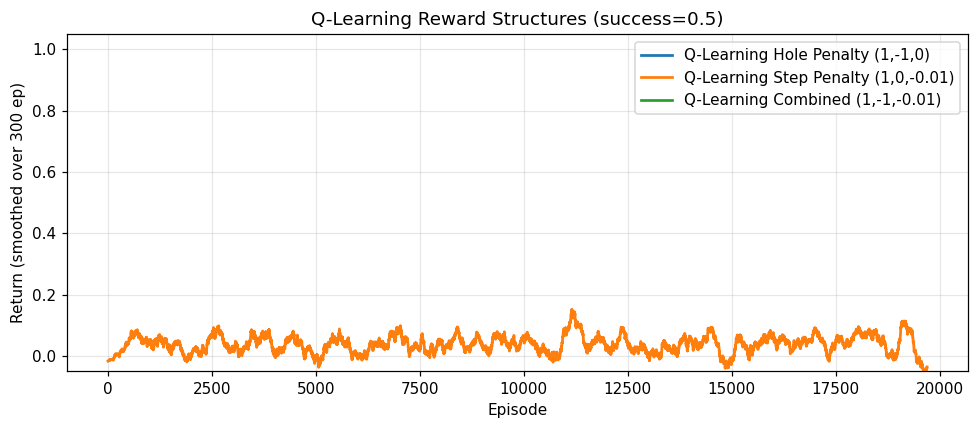

In [22]:
run_ql_reward_experiment(
    map_name="4x4", 
    is_slippery=True, 
    success_rate=50.0/100.0,
    reward_schedules=reward_structures
)

### Q-Learning Reward Structure Lessons
After experimenting with different reward structures for Q-Learning, I found that combined penalties had an incredible effect on the deterministic environment and the step penalty found more success in the stochastic environments. In stochastic environments, the agent may fall in a hole even with good actions due to random slips. Heavy hole penalties can cause it to learn  "all actions near ice are bad" rather than "take the best path despite risk." This leads me to believe that Q-Learning learned to stay away from the ice and found the shortest path in the deterministic environment. I believe the step count made the algorithm "confident" enough to still try to maneuver around the environment without a huge fear of the ice. This makes the agent want to maximize its return by getting to the terminal state in the shortest amount of steps, which is why I believe that the algorithm was too scared in the stochastic environments to move when falling in reduced the return. The step penalty provides a denser reward signal that helps Q-Learning's bootstrapping updates propagate value information more quickly from the goal state backward. I found this addresses its main weakness with sparse rewards.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net).
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)